In [1]:
import rasterio
import numpy as np
import pandas as pd

import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib import pyplot as plt

from joblib import Parallel, delayed #并行运算的库

In [2]:
# 修改工作路径
import os
os.chdir('D:/0_PhdData/0_Paper/4_Global_P/4.2_Global_P_Calculation/') # 修改工作路径

全球数据集

In [3]:
# Global土壤-气候数据读取

dt = pd.read_csv('./5_Model_data/Global_data/Global_data.csv')

# 使用每列的平均值填补 NA 值
dt = dt.apply(lambda x: x.fillna(x.mean()), axis=0)

In [55]:
# 读取数据
dt_phy = pd.read_csv('./5_Model_data/Global_data/crop_phy.csv')

global_phy = pd.DataFrame({
    'rice_phy': dt_phy['har_RICE'],
    'wheat_phy': dt_phy['har_WHEA'],
    'maize_phy': dt_phy['har_MAIZ'],
    'cereals_phy': dt_phy[['har_BARL', 'har_PMIL', 'har_SMIL', 'har_SORG', 'har_OCER']].sum(axis=1),
    'cash_phy': dt_phy[['har_SUGC', 'har_SUGB', 'har_COTT', 'har_OFIB', 'har_ACOF', 'har_RCOF', 'har_COCO', 'har_TEAS', 'har_TOBA', 'har_REST']].sum(axis=1),
    'pulses_phy': dt_phy[['har_BEAN', 'har_CHIC', 'har_COWP', 'har_PIGE', 'har_LENT', 'har_OPUL', 'har_SOYB', 'har_GROU']].sum(axis=1),
    'roots_phy': dt_phy[['har_POTA', 'har_SWPO', 'har_YAMS', 'har_CASS', 'har_ORTS']].sum(axis=1),
    'veg_phy': dt_phy[['har_CNUT', 'har_BANA', 'har_PLNT', 'har_TROF', 'har_TEMF', 'har_VEGE']].sum(axis=1),
    'oil_phy': dt_phy[['har_OILP', 'har_SUNF', 'har_RAPE', 'har_SESA', 'har_OOIL']].sum(axis=1)
})
global_phy['total_phy'] = global_phy.sum()

1. Maize

In [56]:
# 读取数据
ASPT_maize = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Maize.csv')
ESPT_maize = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Maize.csv')

aspt_picture_maize = ASPT_maize.copy()
# 计算分母
denominator = global_phy['maize_phy']

# 当 denominator 为 0 时，把整行设为 NaN
aspt_picture_maize.loc[denominator == 0.0, :] = np.nan
aspt_picture_maize = aspt_picture_maize.dropna()

espt_picture_maize = ESPT_maize.copy()

# 当 denominator 为 0 时，把整行设为 NaN
espt_picture_maize.loc[denominator == 0.0, :] = np.nan
espt_picture_maize = espt_picture_maize.dropna()

2. Rice

In [57]:
# 读取数据
ASPT_rice = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Rice.csv')
ESPT_rice = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Rice.csv')

aspt_picture_rice = ASPT_rice.copy()
# 计算分母
denominator = global_phy['rice_phy']

# 当 denominator 为 0 时，把整行设为 NaN
aspt_picture_rice.loc[denominator == 0.0, :] = np.nan
aspt_picture_rice = aspt_picture_rice.dropna()

espt_picture_rice = ESPT_rice.copy()

# 当 denominator 为 0 时，把整行设为 NaN
espt_picture_rice.loc[denominator == 0.0, :] = np.nan
espt_picture_rice = espt_picture_rice.dropna()

3. Wheat

In [58]:
# 读取数据
ASPT_wheat = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Wheat.csv')
ESPT_wheat = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Wheat.csv')
aspt_picture_wheat = ASPT_wheat.copy()
# 计算分母
denominator = global_phy['wheat_phy']

# 当 denominator 为 0 时，把整行设为 NaN
aspt_picture_wheat.loc[denominator == 0.0, :] = np.nan
aspt_picture_wheat = aspt_picture_wheat.dropna()

espt_picture_wheat = ESPT_wheat.copy()

# 当 denominator 为 0 时，把整行设为 NaN
espt_picture_wheat.loc[denominator == 0.0, :] = np.nan
espt_picture_wheat = espt_picture_wheat.dropna()

4. Other-Cash

In [59]:
# 读取数据
ASPT_cash = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(cash).csv')
ESPT_cash = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Other.csv')
aspt_picture_cash = ASPT_cash.copy()
# 计算分母
denominator = global_phy['cash_phy']

# 当 denominator 为 0 时，把整行设为 NaN
aspt_picture_cash.loc[denominator == 0.0, :] = np.nan
aspt_picture_cash = aspt_picture_cash.dropna()

espt_picture_cash = ESPT_cash.copy()

# 当 denominator 为 0 时，把整行设为 NaN
espt_picture_cash.loc[denominator == 0.0, :] = np.nan
espt_picture_cash = espt_picture_cash.dropna()

5. Other-Cereal crops

In [60]:
# 读取数据
ASPT_cereal = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(cereals).csv')
ESPT_cereal = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Other.csv')
aspt_picture_cereal = ASPT_cereal.copy()
# 计算分母
denominator = global_phy['cereals_phy']

# 当 denominator 为 0 时，把整行设为 NaN
aspt_picture_cereal.loc[denominator == 0.0, :] = np.nan
aspt_picture_cereal = aspt_picture_cereal.dropna()

espt_picture_cereal = ESPT_cereal.copy()

# 当 denominator 为 0 时，把整行设为 NaN
espt_picture_cereal.loc[denominator == 0.0, :] = np.nan
espt_picture_cereal = espt_picture_cereal.dropna()

6. Other-Oil

In [61]:
# 读取数据
ASPT_oil = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(oil).csv')
ESPT_oil = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Other.csv')
aspt_picture_oil = ASPT_oil.copy()
# 计算分母
denominator = global_phy['oil_phy']

# 当 denominator 为 0 时，把整行设为 NaN
aspt_picture_oil.loc[denominator == 0.0, :] = np.nan
aspt_picture_oil = aspt_picture_oil.dropna()

espt_picture_oil = ESPT_oil.copy()

# 当 denominator 为 0 时，把整行设为 NaN
espt_picture_oil.loc[denominator == 0.0, :] = np.nan
espt_picture_oil = espt_picture_oil.dropna()

7. Other-root

In [62]:
# 读取数据
ASPT_root = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(roots).csv')
ESPT_root = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Other.csv')
aspt_picture_root = ASPT_root.copy()
# 计算分母
denominator = global_phy['roots_phy']

# 当 denominator 为 0 时，把整行设为 NaN
aspt_picture_root.loc[denominator == 0.0, :] = np.nan
aspt_picture_root = aspt_picture_root.dropna()

espt_picture_root = ESPT_root.copy()

# 当 denominator 为 0 时，把整行设为 NaN
espt_picture_root.loc[denominator == 0.0, :] = np.nan
espt_picture_root = espt_picture_root.dropna()

8. Other-Veg

In [63]:
# 读取数据
ASPT_veg = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(veg).csv')
ESPT_veg = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Other.csv')
aspt_picture_veg = ASPT_veg.copy()
# 计算分母
denominator = global_phy['veg_phy']

# 当 denominator 为 0 时，把整行设为 NaN
aspt_picture_veg.loc[denominator == 0.0, :] = np.nan
aspt_picture_veg = aspt_picture_veg.dropna()

espt_picture_veg = ESPT_veg.copy()

# 当 denominator 为 0 时，把整行设为 NaN
espt_picture_veg.loc[denominator == 0.0, :] = np.nan
espt_picture_veg = espt_picture_veg.dropna()

9. Other-Pulses

In [64]:
# 读取数据
ASPT_pulses = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_Other(pulses).csv')
ESPT_pulses = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_Other.csv')
aspt_picture_pulses = ASPT_pulses.copy()
# 计算分母
denominator = global_phy['pulses_phy']

# 当 denominator 为 0 时，把整行设为 NaN
aspt_picture_pulses.loc[denominator == 0.0, :] = np.nan
aspt_picture_pulses = aspt_picture_pulses.dropna()

espt_picture_pulses = ESPT_pulses.copy()

# 当 denominator 为 0 时，把整行设为 NaN
espt_picture_pulses.loc[denominator == 0.0, :] = np.nan
espt_picture_pulses = espt_picture_pulses.dropna()

加权平均

In [65]:
# 读取数据
ASPT = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/1_ASPT/ASPT_MEAN.csv')
ESPT = pd.read_csv('./9_MAJOR_REVISION/0_New_Data/Model_output_data/3_ESPT/ESPT_MEAN.csv')

In [66]:
ASPT.mean()

p_threshold    16.673189
dtype: float64

绘制所有的图

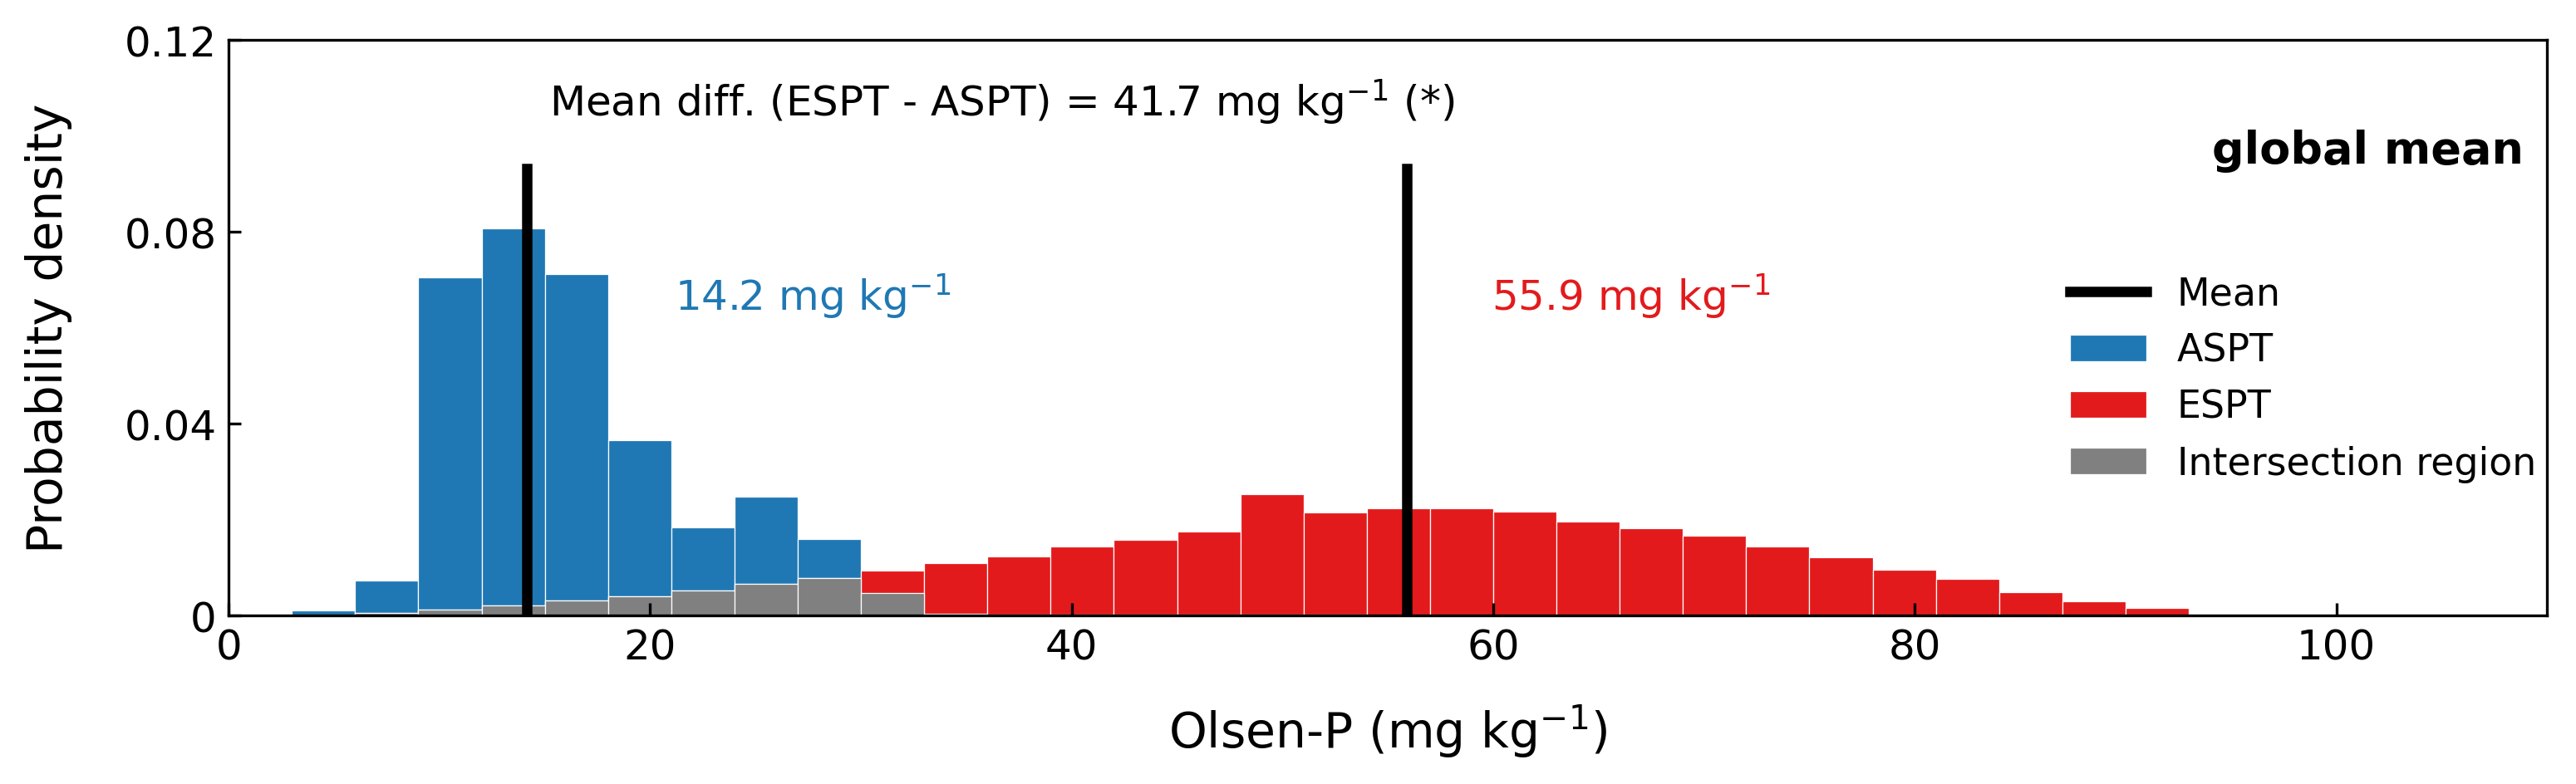

In [68]:
import matplotlib.pyplot as plt
import numpy as np

# 计算均值
mean_espt = float((ESPT.squeeze() * global_phy['rice_phy'].values).sum() / global_phy['rice_phy'].sum())
mean_aspt = float((ASPT.squeeze() * global_phy['rice_phy'].values).sum() / global_phy['rice_phy'].sum())
mean_diff = mean_espt - mean_aspt  # 自动计算差值

# 计算直方图数据
bins = np.linspace(0, 120, 41)  # 设定 bin 范围，确保两个直方图 bin 位置一致
hist_aspt, _ = np.histogram(ASPT, bins=bins, density=True)
hist_espt, _ = np.histogram(ESPT, bins=bins, density=True)

# 计算相交区域
intersection = np.minimum(hist_aspt, hist_espt)  # 计算重叠部分的频率

# 绘制直方图
plt.figure(figsize=(12, 3), dpi=300)
ax = plt.gca()

# 绘制 ASPT 直方图
plt.bar(bins[:-1], hist_aspt, width=np.diff(bins), color='#1F78B4', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ASPT')

# 绘制 ESPT 直方图
plt.bar(bins[:-1], hist_espt, width=np.diff(bins), color='#E31A1C', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ESPT')

# 绘制重叠区域
plt.bar(bins[:-1], intersection, width=np.diff(bins), color='gray', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='Intersection region')

# **控制均值垂直线的长度**
y_min, y_max = ax.get_ylim()  # 获取 y 轴范围
plt.plot([mean_espt, mean_espt], [y_min, y_max * 1.1], color='black', lw=3, label='Mean')  # 80% 高度
plt.plot([mean_aspt, mean_aspt], [y_min, y_max * 1.1], color='black', lw=3)  # 80% 高度

# 在均值垂直线旁边加上文本标签
plt.text(mean_espt + 4, plt.ylim()[1] * 0.65, f"{mean_espt:.1f} mg kg$^{{-1}}$", color='#E31A1C', fontsize=12)
plt.text(mean_aspt + 7, plt.ylim()[1] * 0.65, f"{mean_aspt:.1f} mg kg$^{{-1}}$", color='#1F78B4', fontsize=12)

# 设置 x 轴范围
plt.xlim(0, 110)

# 设置 X 轴刻度间隔为 30
plt.xticks(range(0, 101, 20), fontsize=12)
plt.yticks([0, 0.04, 0.08, 0.12], ['0', '0.04', '0.08', '0.12'], fontsize=12)  # 设置 y 轴数字大小

# 单线边框设置
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

# 添加标题和标签
plt.xlabel('Olsen-P (mg kg$^{-1}$)', fontsize=14, labelpad=10)
plt.ylabel('Probability density', fontsize=14, labelpad=15)

plt.text((plt.xlim()[1]-30) / 2.18, plt.ylim()[1] * 0.85, f'Mean diff. (ESPT - ASPT) = {mean_diff:.1f} mg kg$^{{-1}}$ (*)', 
         fontsize=12, ha='center', va='bottom')

# **右下角加粗 "global mean" 标签**
plt.text(plt.xlim()[1] * 0.99, plt.ylim()[1] * 0.77, 'global mean', 
         fontsize=13, fontweight='bold', ha='right', va='bottom')
ax.tick_params(direction='in')
# **添加图例**
ax.legend(loc='upper right', bbox_to_anchor=(1.01, 0.65), fontsize=11, frameon=False)

# 显示图表

#plt.savefig("test.svg")
plt.show()

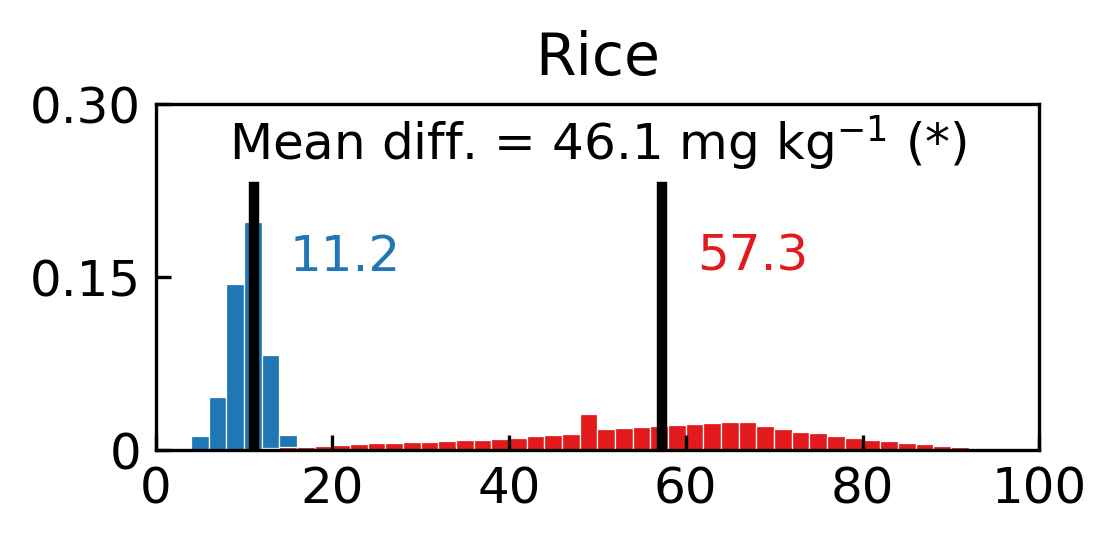

In [70]:
import matplotlib.pyplot as plt
import numpy as np
data_pic_ASPT = ASPT_rice
data_pic_ESPT = ESPT_rice
# 计算均值
mean_espt = float((data_pic_ESPT.squeeze() * global_phy['rice_phy'].values).sum() / global_phy['rice_phy'].sum())
mean_aspt = float((data_pic_ASPT.squeeze() * global_phy['rice_phy'].values).sum() / global_phy['rice_phy'].sum())
mean_diff = mean_espt - mean_aspt  # 自动计算差值

# 计算直方图数据
bins = np.linspace(0, 120, 61)  # 设定 bin 范围，确保两个直方图 bin 位置一致
hist_aspt, _ = np.histogram(data_pic_ASPT, bins=bins, density=True)
hist_espt, _ = np.histogram(data_pic_ESPT, bins=bins, density=True)

# 计算相交区域
intersection = np.minimum(hist_aspt, hist_espt)  # 计算重叠部分的频率

# 绘制直方图
plt.figure(figsize=(3.8, 1.5), dpi=300)
ax = plt.gca()

# 绘制 ASPT 直方图
plt.bar(bins[:-1], hist_aspt, width=np.diff(bins), color='#1F78B4', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ASPT')

# 绘制 ESPT 直方图
plt.bar(bins[:-1], hist_espt, width=np.diff(bins), color='#E31A1C', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ESPT')

# **控制均值垂直线的长度**
y_min, y_max = ax.get_ylim()  # 获取 y 轴范围
plt.plot([mean_espt, mean_espt], [y_min, y_max * 1.1], color='black', lw=2.5, label='Mean')  # 80% 高度
plt.plot([mean_aspt, mean_aspt], [y_min, y_max * 1.1], color='black', lw=2.5)  # 80% 高度

# 在均值垂直线旁边加上文本标签
plt.text(mean_espt + 4, plt.ylim()[1] * 0.65, f"{mean_espt:.1f}", color='#E31A1C', fontsize=12)
plt.text(mean_aspt + 4, plt.ylim()[1] * 0.65, f"{mean_aspt:.1f}", color='#1F78B4', fontsize=12)

# 设置 x 轴范围
plt.xlim(0, 100)

# 设置 X 轴刻度间隔为 30
plt.xticks(range(0, 101, 20), fontsize=12)
plt.yticks([0, 0.15, 0.3], ['0', '0.15', '0.30'], fontsize=12)  # 设置 y 轴数字大小

# 单线边框设置
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

plt.text((plt.xlim()[1] / 2), plt.ylim()[1] * 0.8, f'Mean diff. = {mean_diff:.1f} mg kg$^{{-1}}$ (*)', 
         fontsize=12, ha='center', va='bottom')

ax.tick_params(direction='in')
ax.set_title('Rice', fontsize=14, pad=7)
# 显示图表

#plt.savefig("test.svg")
plt.show()

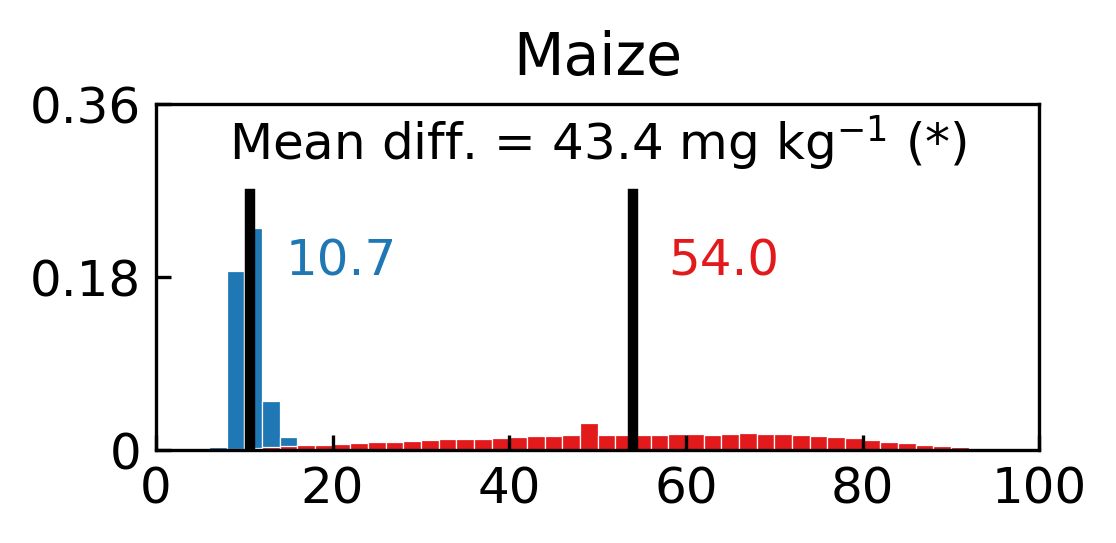

In [72]:
import matplotlib.pyplot as plt
import numpy as np
data_pic_ASPT = ASPT_maize
data_pic_ESPT = ESPT_maize
# 计算均值
mean_espt = float((data_pic_ESPT.squeeze() * global_phy['maize_phy'].values).sum() / global_phy['maize_phy'].sum())
mean_aspt = float((data_pic_ASPT.squeeze() * global_phy['maize_phy'].values).sum() / global_phy['maize_phy'].sum())
mean_diff = mean_espt - mean_aspt  # 自动计算差值

# 计算直方图数据
bins = np.linspace(0, 120, 61)  # 设定 bin 范围，确保两个直方图 bin 位置一致
hist_aspt, _ = np.histogram(data_pic_ASPT, bins=bins, density=True)
hist_espt, _ = np.histogram(data_pic_ESPT, bins=bins, density=True)

# 计算相交区域
intersection = np.minimum(hist_aspt, hist_espt)  # 计算重叠部分的频率

# 绘制直方图
plt.figure(figsize=(3.8, 1.5), dpi=300)
ax = plt.gca()

# 绘制 ASPT 直方图
plt.bar(bins[:-1], hist_aspt, width=np.diff(bins), color='#1F78B4', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ASPT')

# 绘制 ESPT 直方图
plt.bar(bins[:-1], hist_espt, width=np.diff(bins), color='#E31A1C', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ESPT')

# **控制均值垂直线的长度**
y_min, y_max = ax.get_ylim()  # 获取 y 轴范围
plt.plot([mean_espt, mean_espt], [y_min, y_max * 1.1], color='black', lw=2.5, label='Mean')  # 80% 高度
plt.plot([mean_aspt, mean_aspt], [y_min, y_max * 1.1], color='black', lw=2.5)  # 80% 高度

# 在均值垂直线旁边加上文本标签
plt.text(mean_espt + 4, plt.ylim()[1] * 0.65, f"{mean_espt:.1f}", color='#E31A1C', fontsize=12)
plt.text(mean_aspt + 4, plt.ylim()[1] * 0.65, f"{mean_aspt:.1f}", color='#1F78B4', fontsize=12)

# 设置 x 轴范围
plt.xlim(0, 100)

# 设置 X 轴刻度间隔为 30
plt.xticks(range(0, 101, 20), fontsize=12)
plt.yticks([0, 0.18, 0.36], ['0', '0.18', '0.36'], fontsize=12)  # 设置 y 轴数字大小

# 单线边框设置
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

plt.text((plt.xlim()[1] / 2), plt.ylim()[1] * 0.8, f'Mean diff. = {mean_diff:.1f} mg kg$^{{-1}}$ (*)', 
         fontsize=12, ha='center', va='bottom')

ax.tick_params(direction='in')
ax.set_title('Maize', fontsize=14, pad=7)
# 显示图表

#plt.savefig("test.svg")
plt.show()

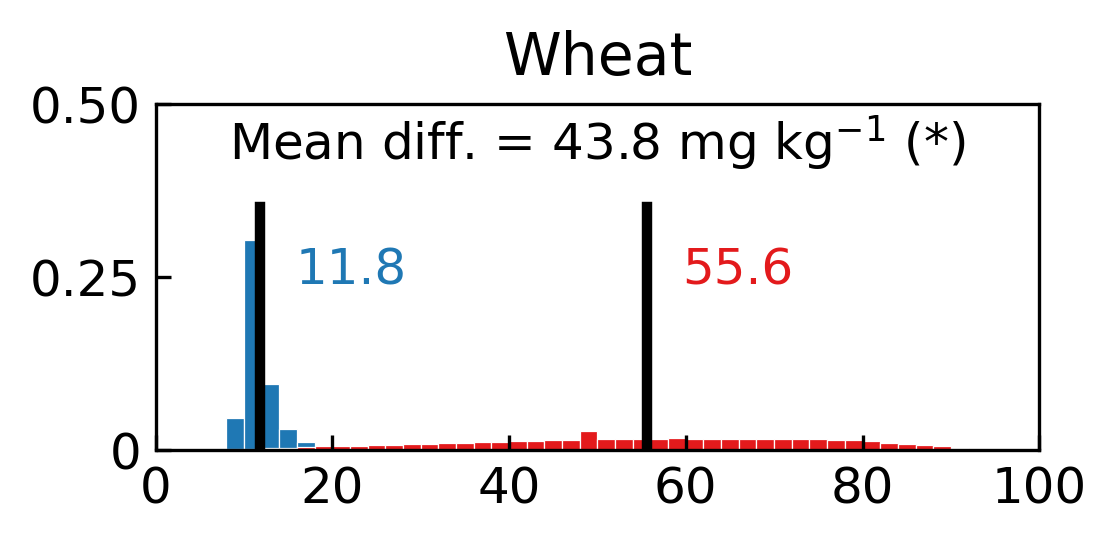

In [74]:
import matplotlib.pyplot as plt
import numpy as np
data_pic_ASPT = ASPT_wheat
data_pic_ESPT = ESPT_wheat
# 计算均值
mean_espt = float((data_pic_ESPT.squeeze() * global_phy['wheat_phy'].values).sum() / global_phy['wheat_phy'].sum())
mean_aspt = float((data_pic_ASPT.squeeze() * global_phy['wheat_phy'].values).sum() / global_phy['wheat_phy'].sum())
mean_diff = mean_espt - mean_aspt  # 自动计算差值

# 计算直方图数据
bins = np.linspace(0, 120, 61)  # 设定 bin 范围，确保两个直方图 bin 位置一致
hist_aspt, _ = np.histogram(data_pic_ASPT, bins=bins, density=True)
hist_espt, _ = np.histogram(data_pic_ESPT, bins=bins, density=True)

# 计算相交区域
intersection = np.minimum(hist_aspt, hist_espt)  # 计算重叠部分的频率

# 绘制直方图
plt.figure(figsize=(3.8, 1.5), dpi=300)
ax = plt.gca()

# 绘制 ASPT 直方图
plt.bar(bins[:-1], hist_aspt, width=np.diff(bins), color='#1F78B4', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ASPT')

# 绘制 ESPT 直方图
plt.bar(bins[:-1], hist_espt, width=np.diff(bins), color='#E31A1C', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ESPT')

# **控制均值垂直线的长度**
y_min, y_max = ax.get_ylim()  # 获取 y 轴范围
plt.plot([mean_espt, mean_espt], [y_min, y_max * 1.1], color='black', lw=2.5, label='Mean')  # 80% 高度
plt.plot([mean_aspt, mean_aspt], [y_min, y_max * 1.1], color='black', lw=2.5)  # 80% 高度

# 在均值垂直线旁边加上文本标签
plt.text(mean_espt + 4, plt.ylim()[1] * 0.65, f"{mean_espt:.1f}", color='#E31A1C', fontsize=12)
plt.text(mean_aspt + 4, plt.ylim()[1] * 0.65, f"{mean_aspt:.1f}", color='#1F78B4', fontsize=12)

# 设置 x 轴范围
plt.xlim(0, 100)

# 设置 X 轴刻度间隔为 30
plt.xticks(range(0, 101, 20), fontsize=12)
plt.yticks([0, 0.25, 0.50], ['0', '0.25', '0.50'], fontsize=12)  # 设置 y 轴数字大小

# 单线边框设置
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

plt.text((plt.xlim()[1] / 2), plt.ylim()[1] * 0.8, f'Mean diff. = {mean_diff:.1f} mg kg$^{{-1}}$ (*)', 
         fontsize=12, ha='center', va='bottom')

ax.tick_params(direction='in')
ax.set_title('Wheat', fontsize=14, pad=7)
# 显示图表

#plt.savefig("test.svg")
plt.show()

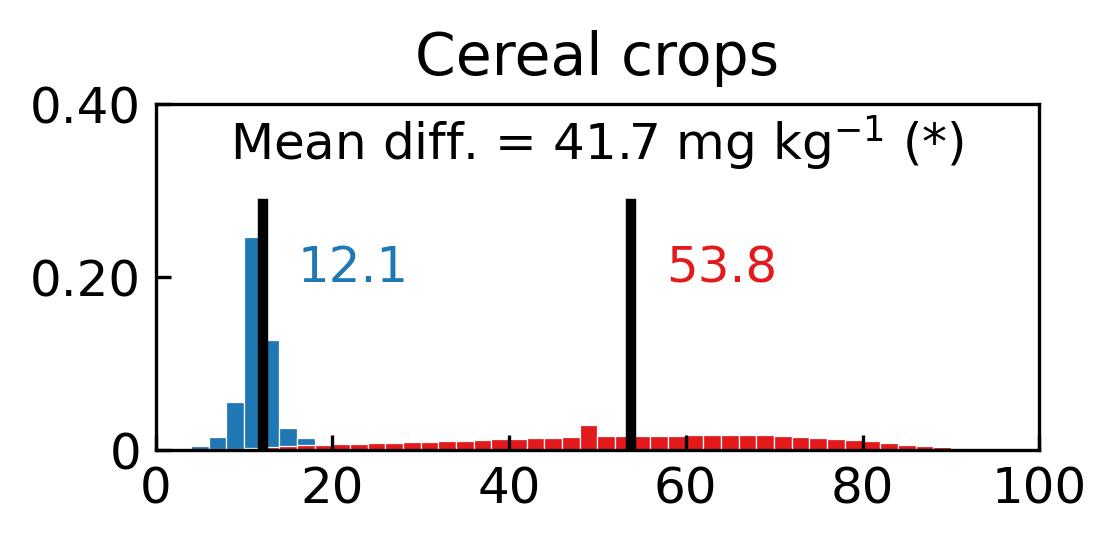

In [75]:
import matplotlib.pyplot as plt
import numpy as np
data_pic_ASPT = ASPT_cereal
data_pic_ESPT = ESPT_cereal
# 计算均值
mean_espt = float((data_pic_ESPT.squeeze() * global_phy['cereals_phy'].values).sum() / global_phy['cereals_phy'].sum())
mean_aspt = float((data_pic_ASPT.squeeze() * global_phy['cereals_phy'].values).sum() / global_phy['cereals_phy'].sum())
mean_diff = mean_espt - mean_aspt  # 自动计算差值

# 计算直方图数据
bins = np.linspace(0, 120, 61)  # 设定 bin 范围，确保两个直方图 bin 位置一致
hist_aspt, _ = np.histogram(data_pic_ASPT, bins=bins, density=True)
hist_espt, _ = np.histogram(data_pic_ESPT, bins=bins, density=True)

# 计算相交区域
intersection = np.minimum(hist_aspt, hist_espt)  # 计算重叠部分的频率

# 绘制直方图
plt.figure(figsize=(3.8, 1.5), dpi=300)
ax = plt.gca()

# 绘制 ASPT 直方图
plt.bar(bins[:-1], hist_aspt, width=np.diff(bins), color='#1F78B4', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ASPT')

# 绘制 ESPT 直方图
plt.bar(bins[:-1], hist_espt, width=np.diff(bins), color='#E31A1C', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ESPT')

# **控制均值垂直线的长度**
y_min, y_max = ax.get_ylim()  # 获取 y 轴范围
plt.plot([mean_espt, mean_espt], [y_min, y_max * 1.1], color='black', lw=2.5, label='Mean')  # 80% 高度
plt.plot([mean_aspt, mean_aspt], [y_min, y_max * 1.1], color='black', lw=2.5)  # 80% 高度

# 在均值垂直线旁边加上文本标签
plt.text(mean_espt + 4, plt.ylim()[1] * 0.65, f"{mean_espt:.1f}", color='#E31A1C', fontsize=12)
plt.text(mean_aspt + 4, plt.ylim()[1] * 0.65, f"{mean_aspt:.1f}", color='#1F78B4', fontsize=12)

# 设置 x 轴范围
plt.xlim(0, 100)

# 设置 X 轴刻度间隔为 30
plt.xticks(range(0, 101, 20), fontsize=12)
plt.yticks([0, 0.2, 0.4], ['0', '0.20', '0.40'], fontsize=12)  # 设置 y 轴数字大小

# 单线边框设置
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

plt.text((plt.xlim()[1] / 2), plt.ylim()[1] * 0.8, f'Mean diff. = {mean_diff:.1f} mg kg$^{{-1}}$ (*)', 
         fontsize=12, ha='center', va='bottom')

ax.tick_params(direction='in')
ax.set_title('Cereal crops', fontsize=14, pad=7)
# 显示图表

#plt.savefig("test.svg")
plt.show()

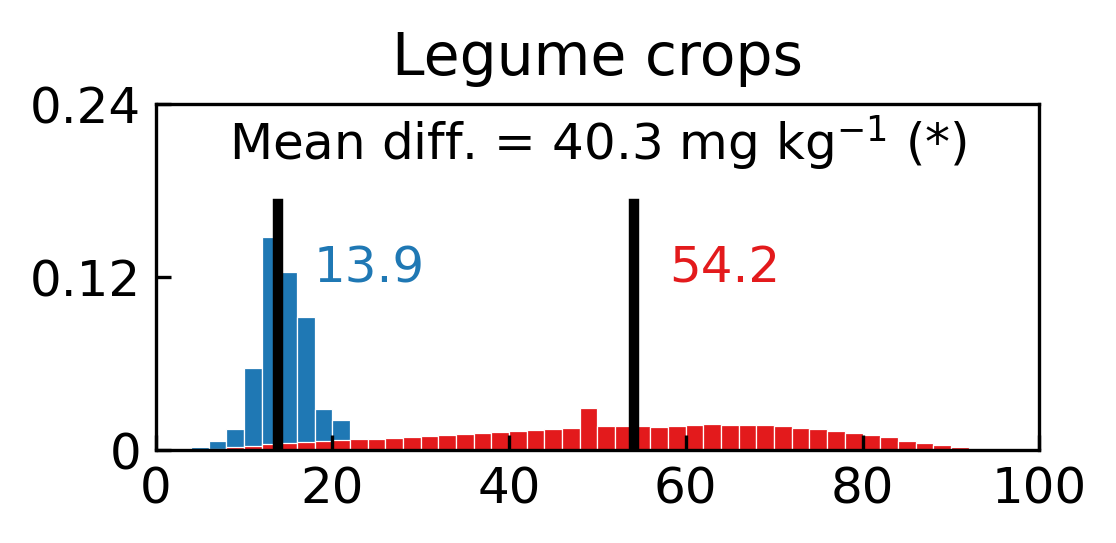

In [77]:
import matplotlib.pyplot as plt
import numpy as np
data_pic_ASPT = ASPT_pulses
data_pic_ESPT = ESPT_pulses
# 计算均值
mean_espt = float((data_pic_ESPT.squeeze() * global_phy['pulses_phy'].values).sum() / global_phy['pulses_phy'].sum())
mean_aspt = float((data_pic_ASPT.squeeze() * global_phy['pulses_phy'].values).sum() / global_phy['pulses_phy'].sum())
mean_diff = mean_espt - mean_aspt  # 自动计算差值

# 计算直方图数据
bins = np.linspace(0, 120, 61)  # 设定 bin 范围，确保两个直方图 bin 位置一致
hist_aspt, _ = np.histogram(data_pic_ASPT, bins=bins, density=True)
hist_espt, _ = np.histogram(data_pic_ESPT, bins=bins, density=True)

# 计算相交区域
intersection = np.minimum(hist_aspt, hist_espt)  # 计算重叠部分的频率

# 绘制直方图
plt.figure(figsize=(3.8, 1.5), dpi=300)
ax = plt.gca()

# 绘制 ASPT 直方图
plt.bar(bins[:-1], hist_aspt, width=np.diff(bins), color='#1F78B4', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ASPT')

# 绘制 ESPT 直方图
plt.bar(bins[:-1], hist_espt, width=np.diff(bins), color='#E31A1C', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ESPT')

# **控制均值垂直线的长度**
y_min, y_max = ax.get_ylim()  # 获取 y 轴范围
plt.plot([mean_espt, mean_espt], [y_min, y_max * 1.1], color='black', lw=2.5, label='Mean')  # 80% 高度
plt.plot([mean_aspt, mean_aspt], [y_min, y_max * 1.1], color='black', lw=2.5)  # 80% 高度

# 在均值垂直线旁边加上文本标签
plt.text(mean_espt + 4, plt.ylim()[1] * 0.65, f"{mean_espt:.1f}", color='#E31A1C', fontsize=12)
plt.text(mean_aspt + 4, plt.ylim()[1] * 0.65, f"{mean_aspt:.1f}", color='#1F78B4', fontsize=12)

# 设置 x 轴范围
plt.xlim(0, 100)

# 设置 X 轴刻度间隔为 30
plt.xticks(range(0, 101, 20), fontsize=12)
plt.yticks([0, 0.12, 0.24], ['0', '0.12', '0.24'], fontsize=12)  # 设置 y 轴数字大小

# 单线边框设置
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

plt.text((plt.xlim()[1] / 2), plt.ylim()[1] * 0.8, f'Mean diff. = {mean_diff:.1f} mg kg$^{{-1}}$ (*)', 
         fontsize=12, ha='center', va='bottom')

ax.tick_params(direction='in')
ax.set_title('Legume crops', fontsize=14, pad=7)
# 显示图表

#plt.savefig("test.svg")
plt.show()

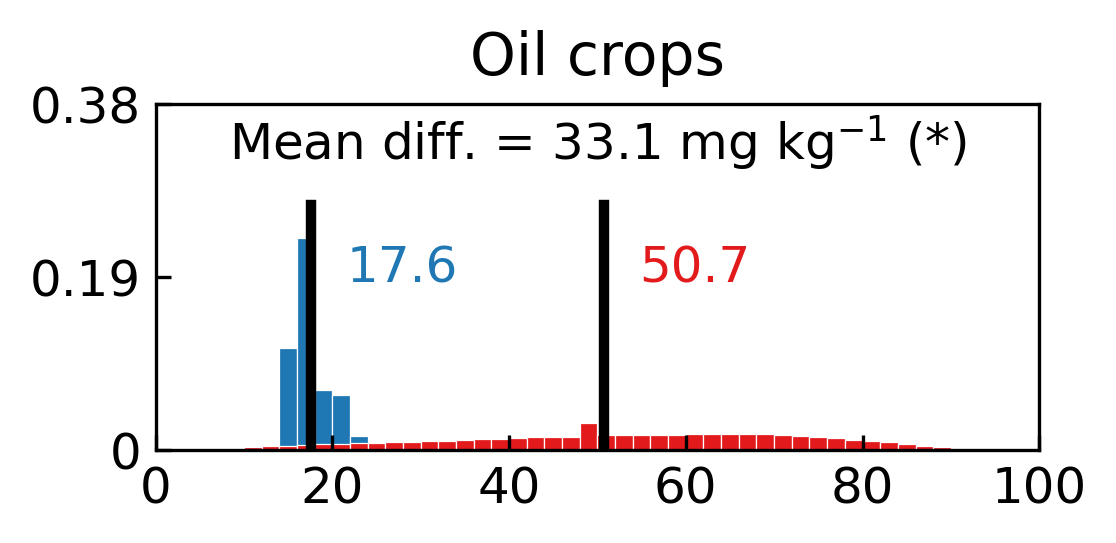

In [79]:
import matplotlib.pyplot as plt
import numpy as np
data_pic_ASPT = ASPT_oil
data_pic_ESPT = ESPT_oil
# 计算均值
mean_espt = float((data_pic_ESPT.squeeze() * global_phy['oil_phy'].values).sum() / global_phy['oil_phy'].sum())
mean_aspt = float((data_pic_ASPT.squeeze() * global_phy['oil_phy'].values).sum() / global_phy['oil_phy'].sum())
mean_diff = mean_espt - mean_aspt  # 自动计算差值

# 计算直方图数据
bins = np.linspace(0, 120, 61)  # 设定 bin 范围，确保两个直方图 bin 位置一致
hist_aspt, _ = np.histogram(data_pic_ASPT, bins=bins, density=True)
hist_espt, _ = np.histogram(data_pic_ESPT, bins=bins, density=True)

# 计算相交区域
intersection = np.minimum(hist_aspt, hist_espt)  # 计算重叠部分的频率

# 绘制直方图
plt.figure(figsize=(3.8, 1.5), dpi=300)
ax = plt.gca()

# 绘制 ASPT 直方图
plt.bar(bins[:-1], hist_aspt, width=np.diff(bins), color='#1F78B4', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ASPT')

# 绘制 ESPT 直方图
plt.bar(bins[:-1], hist_espt, width=np.diff(bins), color='#E31A1C', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ESPT')

# **控制均值垂直线的长度**
y_min, y_max = ax.get_ylim()  # 获取 y 轴范围
plt.plot([mean_espt, mean_espt], [y_min, y_max * 1.1], color='black', lw=2.5, label='Mean')  # 80% 高度
plt.plot([mean_aspt, mean_aspt], [y_min, y_max * 1.1], color='black', lw=2.5)  # 80% 高度

# 在均值垂直线旁边加上文本标签
plt.text(mean_espt + 4, plt.ylim()[1] * 0.65, f"{mean_espt:.1f}", color='#E31A1C', fontsize=12)
plt.text(mean_aspt + 4, plt.ylim()[1] * 0.65, f"{mean_aspt:.1f}", color='#1F78B4', fontsize=12)

# 设置 x 轴范围
plt.xlim(0, 100)

# 设置 X 轴刻度间隔为 30
plt.xticks(range(0, 101, 20), fontsize=12)
plt.yticks([0, 0.19, 0.38], ['0', '0.19', '0.38'], fontsize=12)  # 设置 y 轴数字大小

# 单线边框设置
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

plt.text((plt.xlim()[1] / 2), plt.ylim()[1] * 0.8, f'Mean diff. = {mean_diff:.1f} mg kg$^{{-1}}$ (*)', 
         fontsize=12, ha='center', va='bottom')

ax.tick_params(direction='in')
ax.set_title('Oil crops', fontsize=14, pad=7)
# 显示图表

#plt.savefig("test.svg")
plt.show()

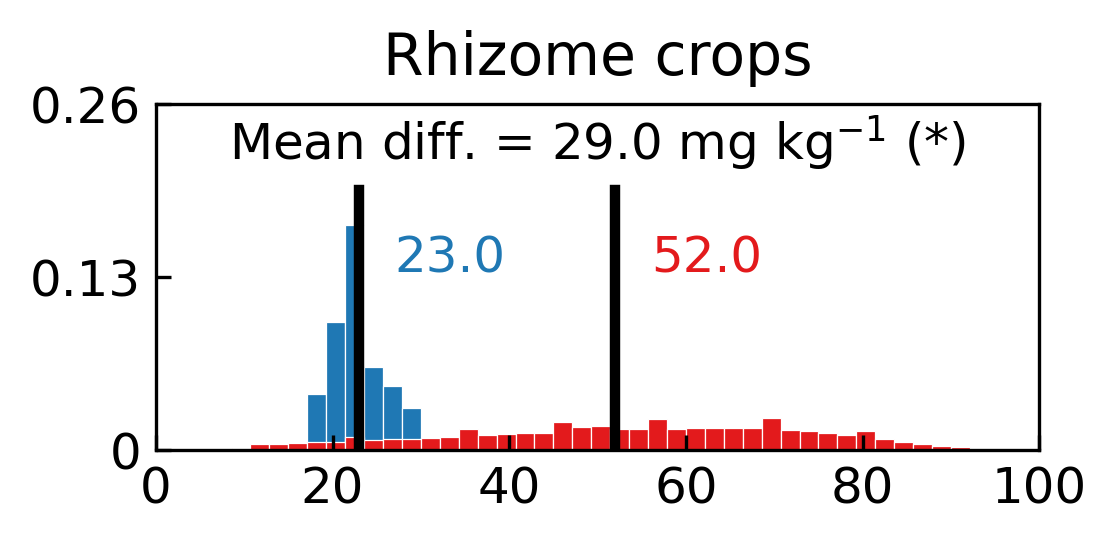

In [80]:
import matplotlib.pyplot as plt
import numpy as np
data_pic_ASPT = ASPT_root
data_pic_ESPT = ESPT_root
# 计算均值
mean_espt = float((data_pic_ESPT.squeeze() * global_phy['roots_phy'].values).sum() / global_phy['roots_phy'].sum())
mean_aspt = float((data_pic_ASPT.squeeze() * global_phy['roots_phy'].values).sum() / global_phy['roots_phy'].sum())
mean_diff = mean_espt - mean_aspt  # 自动计算差值

# 计算直方图数据
bins = np.linspace(0, 120, 57)  # 设定 bin 范围，确保两个直方图 bin 位置一致
hist_aspt, _ = np.histogram(data_pic_ASPT, bins=bins, density=True)
hist_espt, _ = np.histogram(data_pic_ESPT, bins=bins, density=True)

# 计算相交区域
intersection = np.minimum(hist_aspt, hist_espt)  # 计算重叠部分的频率

# 绘制直方图
plt.figure(figsize=(3.8, 1.5), dpi=300)
ax = plt.gca()

# 绘制 ASPT 直方图
plt.bar(bins[:-1], hist_aspt, width=np.diff(bins), color='#1F78B4', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ASPT')

# 绘制 ESPT 直方图
plt.bar(bins[:-1], hist_espt, width=np.diff(bins), color='#E31A1C', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ESPT')

# **控制均值垂直线的长度**
y_min, y_max = ax.get_ylim()  # 获取 y 轴范围
plt.plot([mean_espt, mean_espt], [y_min, y_max * 1.1], color='black', lw=2.5, label='Mean')  # 80% 高度
plt.plot([mean_aspt, mean_aspt], [y_min, y_max * 1.1], color='black', lw=2.5)  # 80% 高度

# 在均值垂直线旁边加上文本标签
plt.text(mean_espt + 4, plt.ylim()[1] * 0.65, f"{mean_espt:.1f}", color='#E31A1C', fontsize=12)
plt.text(mean_aspt + 4, plt.ylim()[1] * 0.65, f"{mean_aspt:.1f}", color='#1F78B4', fontsize=12)

# 设置 x 轴范围
plt.xlim(0, 100)

# 设置 X 轴刻度间隔为 30
plt.xticks(range(0, 101, 20), fontsize=12)
plt.yticks([0, 0.13, 0.26], ['0', '0.13', '0.26'], fontsize=12)  # 设置 y 轴数字大小

# 单线边框设置
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

plt.text((plt.xlim()[1] / 2), plt.ylim()[1] * 0.8, f'Mean diff. = {mean_diff:.1f} mg kg$^{{-1}}$ (*)', 
         fontsize=12, ha='center', va='bottom')

ax.tick_params(direction='in')
ax.set_title('Rhizome crops', fontsize=14, pad=7)
# 显示图表

#plt.savefig("test.svg")
plt.show()

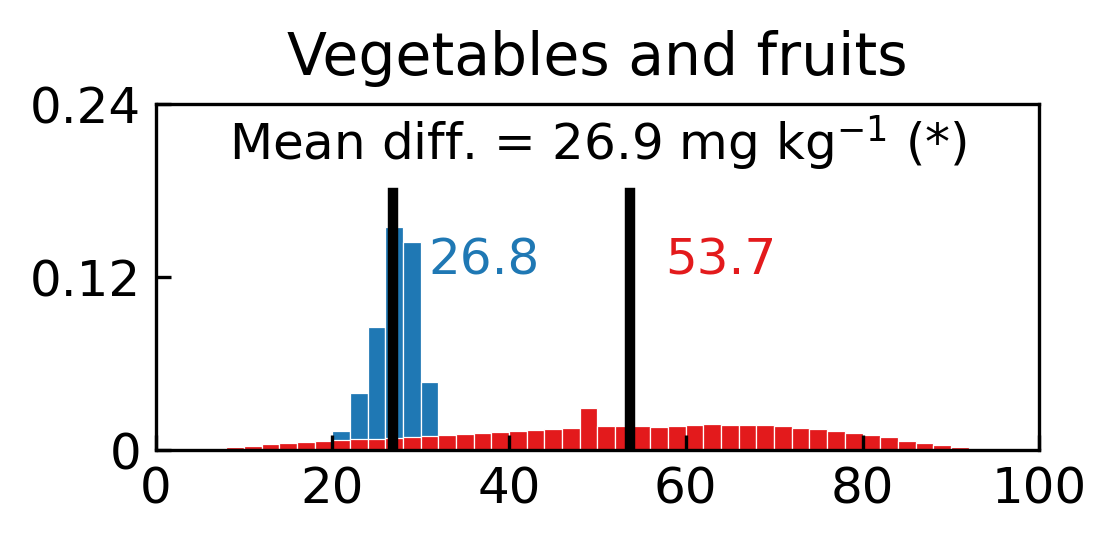

In [82]:
import matplotlib.pyplot as plt
import numpy as np
data_pic_ASPT = ASPT_veg
data_pic_ESPT = ESPT_veg
# 计算均值
mean_espt = float((data_pic_ESPT.squeeze() * global_phy['veg_phy'].values).sum() / global_phy['veg_phy'].sum())
mean_aspt = float((data_pic_ASPT.squeeze() * global_phy['veg_phy'].values).sum() / global_phy['veg_phy'].sum())
mean_diff = mean_espt - mean_aspt  # 自动计算差值

# 计算直方图数据
bins = np.linspace(0, 120, 61)  # 设定 bin 范围，确保两个直方图 bin 位置一致
hist_aspt, _ = np.histogram(data_pic_ASPT, bins=bins, density=True)
hist_espt, _ = np.histogram(data_pic_ESPT, bins=bins, density=True)

# 计算相交区域
intersection = np.minimum(hist_aspt, hist_espt)  # 计算重叠部分的频率

# 绘制直方图
plt.figure(figsize=(3.8, 1.5), dpi=300)
ax = plt.gca()

# 绘制 ASPT 直方图
plt.bar(bins[:-1], hist_aspt, width=np.diff(bins), color='#1F78B4', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ASPT')

# 绘制 ESPT 直方图
plt.bar(bins[:-1], hist_espt, width=np.diff(bins), color='#E31A1C', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ESPT')

# **控制均值垂直线的长度**
y_min, y_max = ax.get_ylim()  # 获取 y 轴范围
plt.plot([mean_espt, mean_espt], [y_min, y_max * 1.1], color='black', lw=2.5, label='Mean')  # 80% 高度
plt.plot([mean_aspt, mean_aspt], [y_min, y_max * 1.1], color='black', lw=2.5)  # 80% 高度

# 在均值垂直线旁边加上文本标签
plt.text(mean_espt + 4, plt.ylim()[1] * 0.65, f"{mean_espt:.1f}", color='#E31A1C', fontsize=12)
plt.text(mean_aspt + 4, plt.ylim()[1] * 0.65, f"{mean_aspt:.1f}", color='#1F78B4', fontsize=12)

# 设置 x 轴范围
plt.xlim(0, 100)

# 设置 X 轴刻度间隔为 30
plt.xticks(range(0, 101, 20), fontsize=12)
plt.yticks([0, 0.12, 0.24], ['0', '0.12', '0.24'], fontsize=12)  # 设置 y 轴数字大小

# 单线边框设置
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

plt.text((plt.xlim()[1] / 2), plt.ylim()[1] * 0.8, f'Mean diff. = {mean_diff:.1f} mg kg$^{{-1}}$ (*)', 
         fontsize=12, ha='center', va='bottom')

ax.tick_params(direction='in')
ax.set_title('Vegetables and fruits', fontsize=14, pad=7)
# 显示图表

#plt.savefig("test.svg")
plt.show()

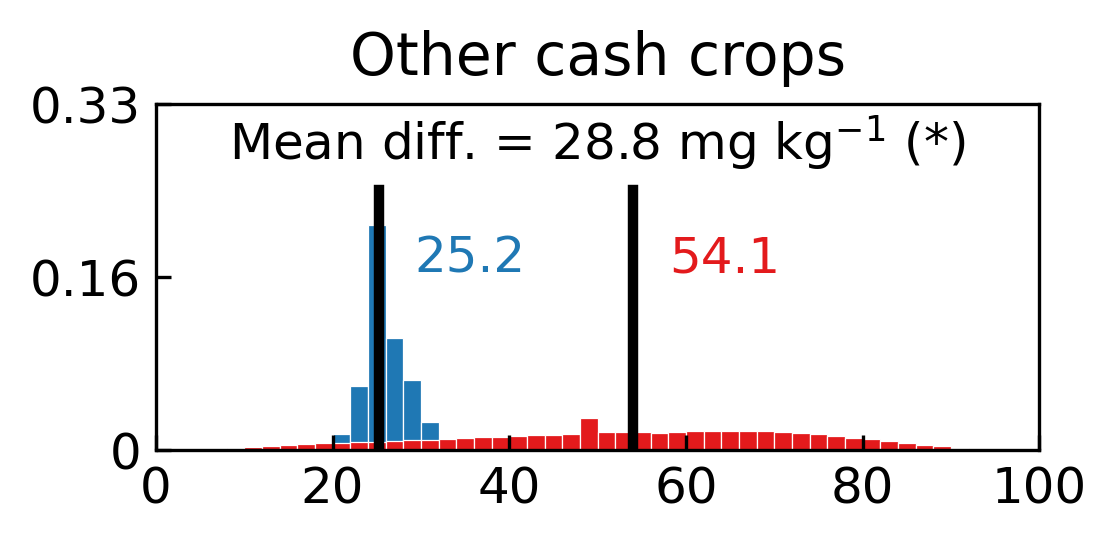

In [83]:
import matplotlib.pyplot as plt
import numpy as np
data_pic_ASPT = ASPT_cash
data_pic_ESPT = ESPT_cash
# 计算均值
mean_espt = float((data_pic_ESPT.squeeze() * global_phy['cash_phy'].values).sum() / global_phy['cash_phy'].sum())
mean_aspt = float((data_pic_ASPT.squeeze() * global_phy['cash_phy'].values).sum() / global_phy['cash_phy'].sum())
mean_diff = mean_espt - mean_aspt  # 自动计算差值

# 计算直方图数据
bins = np.linspace(0, 120, 61)  # 设定 bin 范围，确保两个直方图 bin 位置一致
hist_aspt, _ = np.histogram(data_pic_ASPT, bins=bins, density=True)
hist_espt, _ = np.histogram(data_pic_ESPT, bins=bins, density=True)

# 计算相交区域
intersection = np.minimum(hist_aspt, hist_espt)  # 计算重叠部分的频率

# 绘制直方图
plt.figure(figsize=(3.8, 1.5), dpi=300)
ax = plt.gca()

# 绘制 ASPT 直方图
plt.bar(bins[:-1], hist_aspt, width=np.diff(bins), color='#1F78B4', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ASPT')

# 绘制 ESPT 直方图
plt.bar(bins[:-1], hist_espt, width=np.diff(bins), color='#E31A1C', alpha=1, edgecolor='white', linewidth=0.3, align='edge', label='ESPT')

# **控制均值垂直线的长度**
y_min, y_max = ax.get_ylim()  # 获取 y 轴范围
plt.plot([mean_espt, mean_espt], [y_min, y_max * 1.1], color='black', lw=2.5, label='Mean')  # 80% 高度
plt.plot([mean_aspt, mean_aspt], [y_min, y_max * 1.1], color='black', lw=2.5)  # 80% 高度

# 在均值垂直线旁边加上文本标签
plt.text(mean_espt + 4, plt.ylim()[1] * 0.65, f"{mean_espt:.1f}", color='#E31A1C', fontsize=12)
plt.text(mean_aspt + 4, plt.ylim()[1] * 0.65, f"{mean_aspt:.1f}", color='#1F78B4', fontsize=12)

# 设置 x 轴范围
plt.xlim(0, 100)

# 设置 X 轴刻度间隔为 30
plt.xticks(range(0, 101, 20), fontsize=12)
plt.yticks([0, 0.16, 0.32], ['0', '0.16', '0.33'], fontsize=12)  # 设置 y 轴数字大小

# 单线边框设置
#plt.gca().spines['top'].set_visible(False)
#plt.gca().spines['right'].set_visible(False)

plt.text((plt.xlim()[1] / 2), plt.ylim()[1] * 0.8, f'Mean diff. = {mean_diff:.1f} mg kg$^{{-1}}$ (*)', 
         fontsize=12, ha='center', va='bottom')

ax.tick_params(direction='in')
ax.set_title('Other cash crops', fontsize=14, pad=7)
# 显示图表

#plt.savefig("test.svg")
plt.show()